Dataset_raw

Mục tiêu: chuẩn bị dữ liệu cho bài toán dự đoán `sales_amount`, nhưng dùng target đã log transform là `sales_amount_log`.


## 1. Import thư viện và đọc dữ liệu

**Bước này làm gì?**  
Đọc file `retail_sales_dataset.csv` và nạp các thư viện cần thiết.

**Tác dụng:**  
Tạo DataFrame ban đầu để bắt đầu phân tích và xử lý dữ liệu.


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 6)

from sklearn.preprocessing import StandardScaler

df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


## 2. Data Overview

**Bước này làm gì?**  
Xem kích thước dữ liệu, tên cột, kiểu dữ liệu và thống kê mô tả.

**Tác dụng:**  
Giúp hiểu dữ liệu có bao nhiêu dòng/cột, cột nào là số, cột nào là phân loại, và giá trị dữ liệu phân bố cơ bản như thế nào.


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include='all'))

Shape: (120000, 17)

Columns:
['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  str    
 1   transaction_date    120000 non-null  str    
 2   customer_id         120000 non-null  str    
 3   customer_gender     120000 non-null  str    
 4   customer_age_group  120000 non-null  str    
 5   customer_segment    120000 non-null  str    
 6   product_id          120000 non-null  str    
 7   product_name        120000 non-null  str    
 8   category            120000 non-null  str    
 9   brand               120000 non-null  st

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
count,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000,120000,120000
unique,120000,730,24784,3,5,4,120,40,8,3,NaN,NaN,NaN,NaN,5,3,5
top,T0000001,2025-07-06,C015257,Female,35-44,VIP,P1016,Dumbbells,Sports,Brand 1,NaN,NaN,NaN,NaN,Credit Card,Mobile App,Central
freq,1,200,15,40268,24196,30115,1096,3108,15218,40240,NaN,NaN,NaN,NaN,24262,40204,24244
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.662908,240.621785,5.496500,377.975454,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.014291,146.457057,8.193257,356.893357,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,7.730000,0.000000,5.410000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,102.010000,0.000000,136.860000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,238.750000,0.000000,295.980000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,379.000000,10.000000,461.500000,NaN,NaN,NaN


## 3. Missing Data Analysis và Duplicate

**Bước này làm gì?**  
Kiểm tra dữ liệu thiếu và dòng bị trùng.

**Tác dụng:**  
Nếu có missing value hoặc duplicate thì cần xử lý trước khi train model để tránh dữ liệu sai lệch.


In [4]:
missing_table = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(2)
})

print("Missing values:")
display(missing_table)

print("Duplicate rows:", df.duplicated().sum())

Missing values:


,missing_count,missing_percent
transaction_id,0,0.0
transaction_date,0,0.0
customer_id,0,0.0
customer_gender,0,0.0
customer_age_group,0,0.0
customer_segment,0,0.0
product_id,0,0.0
product_name,0,0.0
category,0,0.0
brand,0,0.0


Duplicate rows: 0


## 4. Loại bỏ cột ID

**Bước này làm gì?**  
Xóa các cột định danh như `transaction_id`, `customer_id`, `product_id`.

**Tác dụng:**  
Các cột ID thường chỉ là mã nhận diện, không mang ý nghĩa dự đoán thực tế. Nếu giữ lại, model có thể học sai theo mã ID.


In [5]:
df = df.drop(['transaction_id', 'customer_id', 'product_id'], axis=1)
print("Shape after dropping ID columns:", df.shape)
df.head()

Shape after dropping ID columns: (120000, 14)


,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,2024-04-24,Other,35-44,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,2025-07-12,Other,45-54,New,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,2025-06-01,Male,55+,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,2025-08-26,Male,25-34,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,2024-12-10,Male,45-54,New,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


## 5. Univariate Analysis

**Bước này làm gì?**  
Phân tích từng biến riêng lẻ: biến số và biến phân loại.

**Tác dụng:**  
Giúp biết biến số có phân phối lệch không, biến phân loại có nhóm nào chiếm tỷ lệ quá cao không.


In [6]:
# Numerical features
num_cols = ['quantity', 'unit_price', 'discount_pct', 'sales_amount']
print("Numerical statistics:")
display(df[num_cols].describe().T)
# Average sales_amount by category
display(df.groupby('category')['sales_amount'].mean().sort_values(ascending=False))

# Average sales_amount by transaction_month
_temp_date = pd.to_datetime(df['transaction_date'])
df_temp_month = df.copy()
df_temp_month['transaction_month'] = _temp_date.dt.month
display(df_temp_month.groupby('transaction_month')['sales_amount'].mean())


Numerical statistics:


,count,mean,std,min,25%,50%,75%,max
quantity,120000.0,1.662908,1.014291,1.00,1.00,1.00,2.0,5.00
unit_price,120000.0,240.621785,146.457057,7.73,102.01,238.75,379.0,493.51
discount_pct,120000.0,5.496500,8.193257,0.00,0.00,0.00,10.0,30.00
sales_amount,120000.0,377.975454,356.893357,5.41,136.86,295.98,461.5,2467.55


category
Beauty         421.662458
Books          412.560984
Electronics    390.437546
Sports         385.291810
Home           378.729177
Toys           369.961536
Groceries      361.283533
Clothing       305.382650
Name: sales_amount, dtype: float64

transaction_month
1     382.285749
2     380.604803
3     366.097330
4     377.492002
5     377.363223
6     375.363405
7     382.906178
8     384.756802
9     375.368337
10    377.528605
11    378.945343
12    376.915208
Name: sales_amount, dtype: float64

## 6. Bivariate / Multivariate Analysis

**Bước này làm gì?**  
Xem quan hệ giữa các biến với target `sales_amount`.

**Tác dụng:**  
Giúp xác định biến nào có liên quan đến doanh số, từ đó hỗ trợ chọn và tạo đặc trưng cho model.


,quantity,unit_price,discount_pct,sales_amount
quantity,1.000000,-0.001101,0.001618,0.644725
unit_price,-0.001101,1.000000,-0.000484,0.643164
discount_pct,0.001618,-0.000484,1.000000,-0.091330
sales_amount,0.644725,0.643164,-0.091330,1.000000


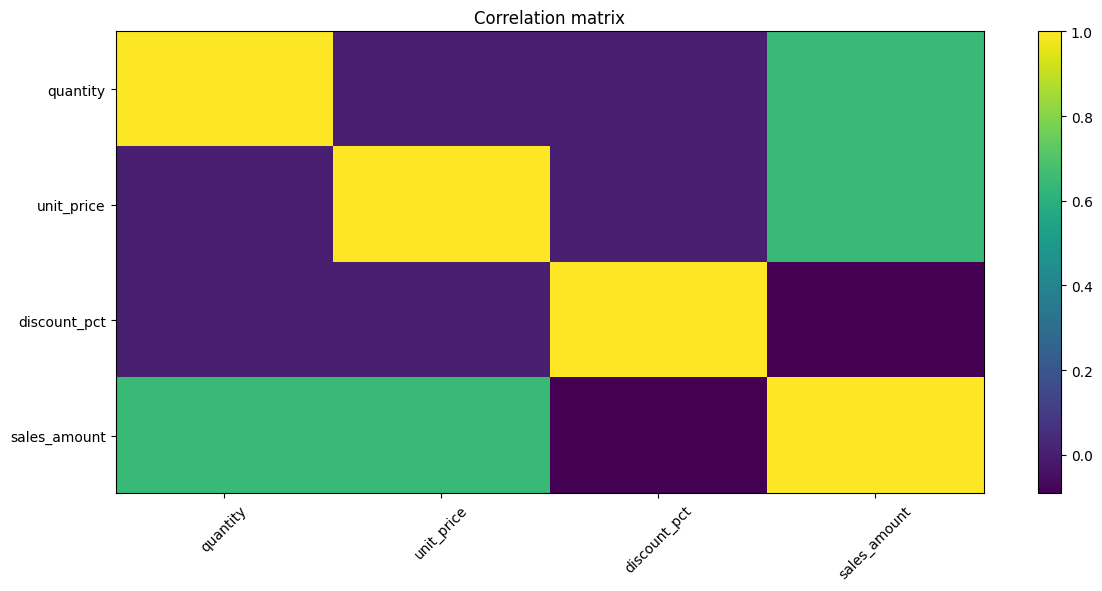

In [7]:
# Numerical vs Numerical: correlation matrix
corr = df[num_cols].corr()
display(corr)

plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix")
plt.show()


## 7. Outlier Detection

**Bước này làm gì?**  
Phát hiện outlier cho `sales_amount` bằng IQR và Z-score.

**Tác dụng:**  
Giúp biết target có giá trị quá cao/thấp bất thường không. Ở đây chỉ phát hiện, **không xóa**, vì doanh số cao vẫn có thể là giao dịch thật.


IQR outlier summary:
{'column': 'sales_amount', 'lower_limit': np.float64(-350.09999999999997), 'upper_limit': np.float64(948.46), 'outlier_count': 8309, 'outlier_percent': 6.92}
Z-score outlier count: 2846
Z-score outlier percent: 2.37


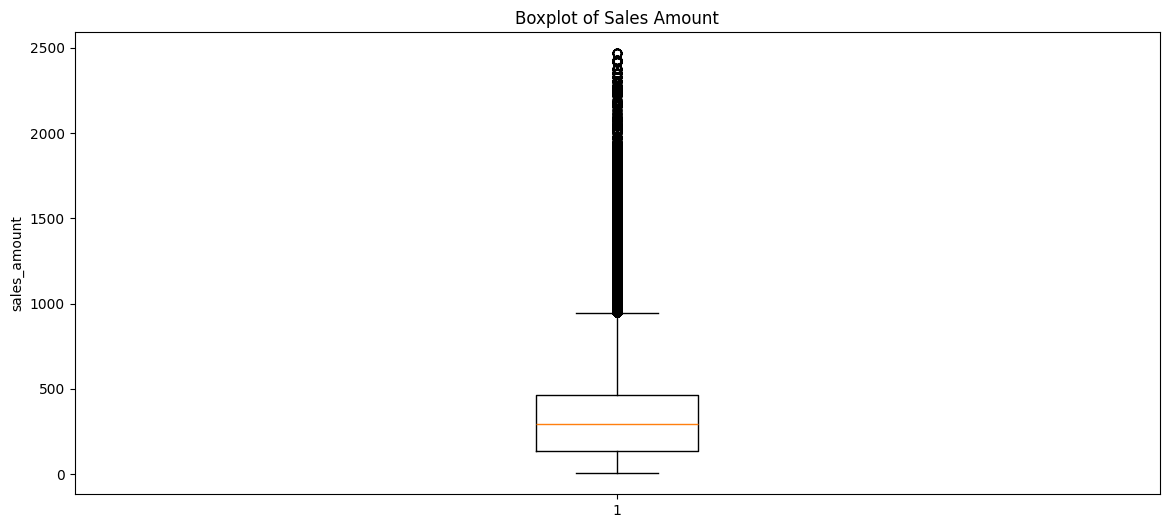

In [8]:
def iqr_outlier_summary(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return {
        'column': column,
        'lower_limit': lower,
        'upper_limit': upper,
        'outlier_count': len(outliers),
        'outlier_percent': round(len(outliers) / len(data) * 100, 2)
    }

iqr_summary = iqr_outlier_summary(df, 'sales_amount')
print("IQR outlier summary:")
print(iqr_summary)

z_score = (df['sales_amount'] - df['sales_amount'].mean()) / df['sales_amount'].std()
z_outlier_count = (z_score.abs() > 3).sum()
print("Z-score outlier count:", z_outlier_count)
print("Z-score outlier percent:", round(z_outlier_count / len(df) * 100, 2))

plt.boxplot(df['sales_amount'])
plt.title("Boxplot of Sales Amount")
plt.ylabel("sales_amount")
plt.show()

## 8. Feature Engineering trước khi split

**Bước này làm gì?**  
Tạo `sales_amount_log`, chuyển ngày tháng, mã hóa nhóm tuổi.

**Tác dụng:**  
- Log transform giúp giảm độ lệch của target.  
- Date features giúp model học xu hướng theo tháng/ngày/thứ.  
- Ordinal encoding biến nhóm tuổi thành số có thứ tự.


Rows with age mapping error: 0


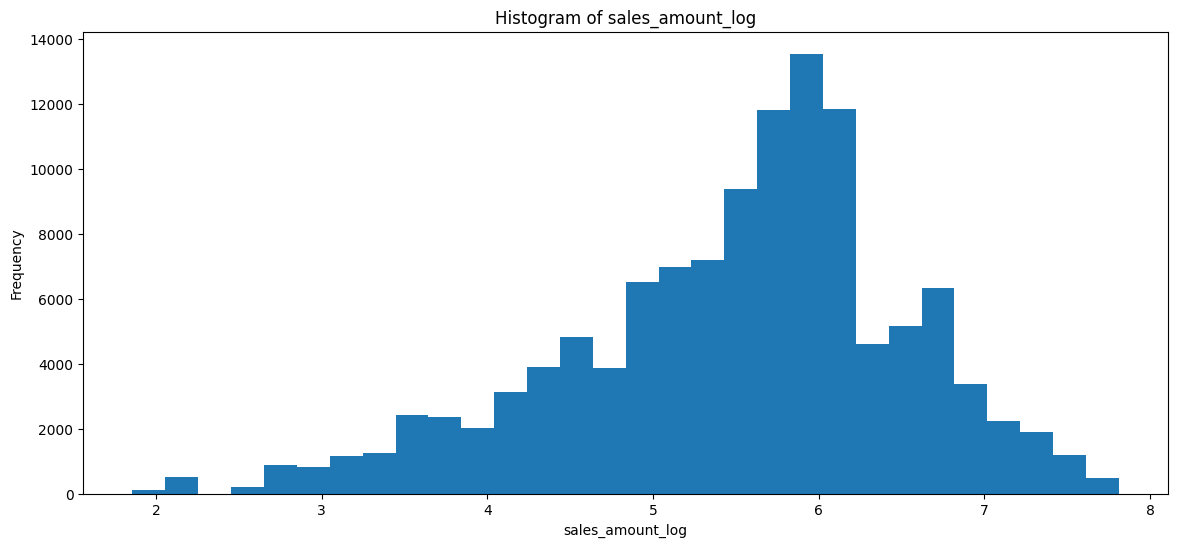

In [9]:
# Log transform target
df['sales_amount_log'] = np.log1p(df['sales_amount'])

# Convert datetime and create date features
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_year'] = df['transaction_date'].dt.year
df['transaction_month'] = df['transaction_date'].dt.month
df['transaction_day'] = df['transaction_date'].dt.day
df['transaction_dayofweek'] = df['transaction_date'].dt.dayofweek

# Ordinal encoding for age group
age_mapping = {
    '18-24': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55+': 4
}
df['customer_age_group_encoded'] = df['customer_age_group'].map(age_mapping)

print("Rows with age mapping error:", df['customer_age_group_encoded'].isna().sum())

plt.hist(df['sales_amount_log'], bins=30)
plt.title("Histogram of sales_amount_log")
plt.xlabel("sales_amount_log")
plt.ylabel("Frequency")
plt.show()

## 9. Split train/test theo thời gian

**Bước này làm gì?**  
Sắp xếp dữ liệu theo `transaction_date`, sau đó chia 80% dữ liệu cũ làm train và 20% dữ liệu mới làm test.

**Tác dụng:**  
Tránh lỗi dùng dữ liệu tương lai để dự đoán quá khứ. Cách này an toàn hơn random split khi dữ liệu có yếu tố thời gian.


In [10]:
df = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_raw = df.iloc[:split_idx].copy()
test_raw = df.iloc[split_idx:].copy()

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Train date range:", train_raw['transaction_date'].min(), "to", train_raw['transaction_date'].max())
print("Test date range :", test_raw['transaction_date'].min(), "to", test_raw['transaction_date'].max())

Train shape: (96000, 20)
Test shape: (24000, 20)
Train date range: 2024-01-01 00:00:00 to 2025-08-07 00:00:00
Test date range : 2025-08-07 00:00:00 to 2025-12-30 00:00:00


## 10. Rolling feature sau khi split để tránh leakage

**Bước này làm gì?**  
Tạo `qty_roll_mean_30d`: số lượng bán trung bình 30 ngày trước của từng sản phẩm.

**Tác dụng:**  
Giúp model học xu hướng bán gần đây.  
Quan trọng: rolling feature được tạo **sau khi split**, và test không dùng `quantity` của chính test để tính lịch sử.


In [11]:
def add_qty_roll_mean_30d_no_leak(train_df, test_df):
    train_temp = train_df.copy()
    test_temp = test_df.copy()

    train_temp['is_test'] = 0
    test_temp['is_test'] = 1

    # Không cho test dùng quantity của chính test để tạo rolling history
    test_temp['quantity_for_rolling'] = np.nan
    train_temp['quantity_for_rolling'] = train_temp['quantity']

    combined = pd.concat([train_temp, test_temp], axis=0)
    combined = combined.sort_values(['product_name', 'transaction_date']).reset_index(drop=True)

    rolling = (
        combined.groupby('product_name')
        .rolling('30D', on='transaction_date', closed='left')['quantity_for_rolling']
        .mean()
    )

    combined['qty_roll_mean_30d'] = rolling.values
    combined['qty_roll_mean_30d'] = combined['qty_roll_mean_30d'].fillna(0)
    combined = combined.drop(columns=['quantity_for_rolling'])

    train_fe = combined[combined['is_test'] == 0].drop(columns=['is_test'])
    test_fe = combined[combined['is_test'] == 1].drop(columns=['is_test'])

    return train_fe, test_fe

train_fe, test_fe = add_qty_roll_mean_30d_no_leak(train_raw, test_raw)

print(train_fe[['product_name', 'transaction_date', 'quantity', 'qty_roll_mean_30d']].head())

  product_name transaction_date  quantity  qty_roll_mean_30d
0     Bedsheet       2024-01-01         1                0.0
1     Bedsheet       2024-01-01         2                0.0
2     Bedsheet       2024-01-01         1                0.0
3     Bedsheet       2024-01-01         2                0.0
4     Bedsheet       2024-01-01         1                0.0


## 11. Encoding categorical variables

**Bước này làm gì?**  
One-hot encoding các biến phân loại trực tiếp trên `train_data` và `test_data`.

**Tác dụng:**  
Chuyển dữ liệu chữ thành dạng số 0/1 để model có thể học được.  
Ở bản này, em **không tách riêng `X_train`, `y_train`**. Dữ liệu train/test vẫn nằm trong cùng một bảng, trong đó có cả feature và target `sales_amount_log`.


In [12]:
# Không tách riêng X_train, y_train
# Xử lý trực tiếp trên train_data và test_data

# Bỏ các cột không dùng trực tiếp cho model
# Giữ sales_amount_log làm target trong cùng dataframe
# Bỏ sales_amount gốc để tránh dùng trực tiếp target gốc khi train model với sales_amount_log
drop_cols = ['sales_amount', 'transaction_date', 'quantity', 'customer_age_group']

train_data = train_fe.drop(columns=drop_cols).copy()
test_data = test_fe.drop(columns=drop_cols).copy()

ohe_columns = [
    'customer_gender', 'customer_segment', 'product_name',
    'category', 'brand', 'payment_method', 'sales_channel', 'region'
]

train_data = pd.get_dummies(train_data, columns=ohe_columns, dtype=int)
test_data = pd.get_dummies(test_data, columns=ohe_columns, dtype=int)

# Căn chỉnh để test có đúng các cột như train
test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

print("Train data shape after encoding:", train_data.shape)
print("Test data shape after encoding :", test_data.shape)
print("Target column kept in data:", 'sales_amount_log' in train_data.columns)


Train data shape after encoding: (96000, 80)
Test data shape after encoding : (24000, 80)
Target column kept in data: True


## 12. Scaling đúng cách

**Bước này làm gì?**  
Chuẩn hóa các feature số bằng StandardScaler.

**Tác dụng:**  
Đưa các biến số về cùng thang đo, giúp các model như Linear Regression, Ridge, Lasso, KNN, SVR học ổn hơn.

**Điểm quan trọng:**  
Scaler chỉ `fit` trên tập train, sau đó `transform` cho tập test.  
Target `sales_amount_log` vẫn được giữ trong dataframe nhưng **không bị scale chung với feature**.


In [13]:
df.groupby('transaction_month')['sales_amount'].mean()

transaction_month
1     382.285749
2     380.604803
3     366.097330
4     377.492002
5     377.363223
6     375.363405
7     382.906178
8     384.756802
9     375.368337
10    377.528605
11    378.945343
12    376.915208
Name: sales_amount, dtype: float64

In [14]:
numeric_cols_to_scale = [
    'unit_price',
    'discount_pct',
    'customer_age_group_encoded',
    'qty_roll_mean_30d',
    'transaction_year',
    'transaction_month',
    'transaction_day',
    'transaction_dayofweek'
]

feature_scaler = StandardScaler()

# Scale trực tiếp trên train_data và test_data, không tách X/y
train_data[numeric_cols_to_scale] = feature_scaler.fit_transform(train_data[numeric_cols_to_scale])
test_data[numeric_cols_to_scale] = feature_scaler.transform(test_data[numeric_cols_to_scale])

print("Scaled numerical features in train:")
display(train_data[numeric_cols_to_scale].describe().round(2))


Scaled numerical features in train:


,unit_price,discount_pct,customer_age_group_encoded,qty_roll_mean_30d,transaction_year,transaction_month,transaction_day,transaction_dayofweek
count,96000.00,96000.00,96000.00,96000.00,96000.00,96000.00,96000.00,96000.0
mean,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.0
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0
min,-1.59,-0.67,-1.42,-13.86,-0.77,-1.43,-1.65,-1.5
25%,-0.94,-0.67,-0.71,-0.52,-0.77,-0.81,-0.86,-1.0
50%,-0.02,-0.67,-0.00,-0.01,-0.77,-0.19,0.04,-0.0
75%,0.94,0.55,0.70,0.54,1.29,0.74,0.84,1.0
max,1.72,2.99,1.41,7.02,1.29,1.98,1.74,1.5


## 13. Lưu dữ liệu sau xử lý

**Bước này làm gì?**  
Lưu trực tiếp `train_data` và `test_data` thành hai file CSV.

**Tác dụng:**  
Tạo dữ liệu sạch để nhóm có thể dùng cho bước train model.  
Bản này **không tách riêng `X_train`, `y_train`** và cũng **không cần ghép X/y ở cuối**, vì target `sales_amount_log` đã nằm sẵn trong bảng train/test.


In [15]:
train_data.to_csv('retail_train_80.csv', index=False)
test_data.to_csv('retail_test_20.csv', index=False)

print("Saved files:")
print("retail_train_80.csv")
print("retail_test_20.csv")
print("Final train shape:", train_data.shape)
print("Final test shape :", test_data.shape)
print("Target column:", 'sales_amount_log')


Saved files:
retail_train_80.csv
retail_test_20.csv
Final train shape: (96000, 80)
Final test shape : (24000, 80)
Target column: sales_amount_log
